In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

sampling_methods = ['r3', 'random', 'randomr']
obj_dict = {method:{} for method in sampling_methods}
for method in sampling_methods:
    obj_dict[method]["L1_list"] = []
    obj_dict[method]["L2_list"] = []

for i in range(10):
    # Define Geometry and Computational Domain
    area = df.geometry.rectangle([-1, 1], [0, 1])
    line_ic = df.geometry.line_horizontal(y=0, range_x=[-1,1])
    line_bc1 = df.geometry.line_vertical(x=-1, range_y=[0,1])
    line_bc2 = df.geometry.line_vertical(x=1, range_y=[0,1])
    domain = df.domain(area.area_list, line_ic, line_bc1, line_bc2)

    # Define PDE
    from torch import sin, pi
    domain.area_list[0].define_pde(df.pde.BurgersEquation1D(nu=0.01/pi))
    domain.bound_list[0].define_bc({'u':['x', lambda x: -sin(pi * x)]})
    domain.bound_list[1].define_bc({'u': 0})
    domain.bound_list[2].define_bc({'u': 0})

    model0 = df.PINN(input_vars=['x', 'y'], output_vars=['u'], width=16, length=4)

    def do_random(epoch, model):
        pass
    obj_dict["random"]["do"] = do_random
    obj_dict["random"]["lr"] = 0.004

    def do_randomr(epoch, model):
        if epoch % 50 == 0 and epoch > 0:
            domain.sampling_lhs([1000, 500, 500], [4000])
    obj_dict["randomr"]["do"] = do_randomr
    obj_dict["randomr"]["lr"] = 0.004

    def do_r3(epoch, model):
        if epoch % 50 == 0 and epoch > 0:
            domain.sampling_lhs([1000, 500, 500])
        if epoch > 0:
            domain.sampling_R3([], [4000])
    obj_dict["r3"]["do"] = do_r3
    obj_dict["r3"]["lr"] = 0.004


    for method in sampling_methods:
        domain.sampling_lhs([1000, 500, 500], [4000])
        obj_dict[method]["model"], _ = model0.train_adam(
            calc_loss = df.calc_loss_weighted(domain, bc_weights=1),
            learning_rate=obj_dict[method]["lr"],
            epochs=5000,
            do_between_epochs=obj_dict[method]["do"],
            print_every=1000)

    import numpy as np
    with open('../../EXPERIMENTS/burgers_reference_solution/burgers_solution.txt', 'r') as f:
        data = np.loadtxt(f)
    x, y, u = data[:, 0], data[:, 1], data[:, 2]

    import torch
    domain_test = df.custom_data({'x':torch.tensor(x, dtype=torch.float32), 'y':torch.tensor(y, dtype=torch.float32)})

    for method in sampling_methods:
        prediction = obj_dict[method]["prediction"] = domain_test.evaluate(obj_dict[method]["model"])
        prediction['u_sol'] = u
        prediction['u_error'] = np.abs(prediction['u']-prediction['u_sol'])
        obj_dict[method]['L2'] = np.sqrt(np.sum(prediction['u_error']**2)/np.sum(prediction['u_sol']**2))
        obj_dict[method]['L1'] = np.sum(prediction['u_error'])/np.sum(np.abs(prediction['u_sol']))

        print('L2 error for method', method, ':', obj_dict[method]['L2'])
        print('L1 error for method', method, ':', obj_dict[method]['L1'])
        obj_dict[method]['L2_list'].append(obj_dict[method]['L2'])
        obj_dict[method]['L1_list'].append(obj_dict[method]['L1'])

Deepflow is runned on: cuda
Epoch: 1, total_loss: 0.65492, bc_loss: 0.65189, pde_loss: 0.00303
Epoch: 1000, total_loss: 0.15464, bc_loss: 0.12399, pde_loss: 0.03065
Epoch: 2000, total_loss: 0.10697, bc_loss: 0.07641, pde_loss: 0.03057
Epoch: 3000, total_loss: 0.03024, bc_loss: 0.01715, pde_loss: 0.01309
Epoch: 4000, total_loss: 0.01640, bc_loss: 0.00705, pde_loss: 0.00935
Epoch: 5000, total_loss: 0.00815, bc_loss: 0.00388, pde_loss: 0.00427
Epoch: 5000, total_loss: 0.00815, bc_loss: 0.00388, pde_loss: 0.00427
Epoch: 1, total_loss: 0.65503, bc_loss: 0.65200, pde_loss: 0.00302
Epoch: 1000, total_loss: 0.08502, bc_loss: 0.05040, pde_loss: 0.03463
Epoch: 2000, total_loss: 0.04446, bc_loss: 0.02403, pde_loss: 0.02043
Epoch: 3000, total_loss: 0.00711, bc_loss: 0.00249, pde_loss: 0.00461
Epoch: 4000, total_loss: 0.00406, bc_loss: 0.00144, pde_loss: 0.00263
Epoch: 5000, total_loss: 0.00415, bc_loss: 0.00120, pde_loss: 0.00294
Epoch: 5000, total_loss: 0.00415, bc_loss: 0.00120, pde_loss: 0.0029

r3 L2: 0.2836899781066754
r3 L1: 0.16794413020964521
random L2: 0.19664167942229055
random L1: 0.05153829990581427
randomr L2: 0.09217890345669921
randomr L1: 0.028560508235416022


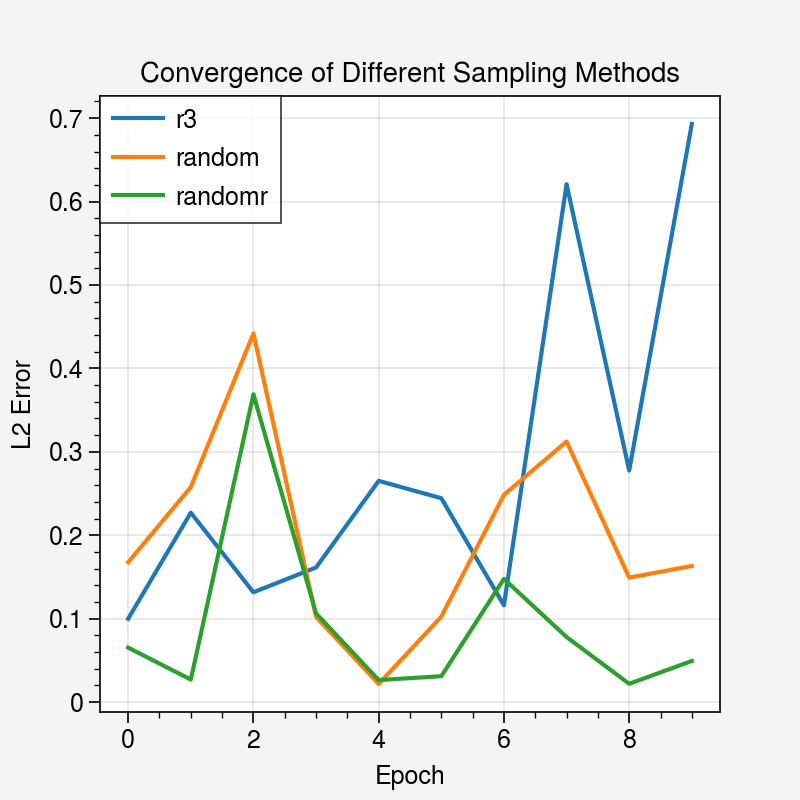

In [2]:
for method in sampling_methods:
    print(method + " L2:", np.mean(obj_dict[method]['L2_list']))
    print(method + " L1:", np.mean(obj_dict[method]['L1_list']))

import matplotlib.pyplot as plt
for method in sampling_methods:
    plt.plot(obj_dict[method]['L2_list'], label=method)
plt.xlabel('Epoch')
plt.ylabel('L2 Error')
plt.title('Convergence of Different Sampling Methods')
plt.legend()
plt.show()